In [436]:
from pyexpat import features

import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

from empyrical import cum_returns

warnings.filterwarnings("ignore")

In [437]:
# Data
df = pd.read_csv("/Users/akash/PycharmProjects/Quant/Regression/market_data/WHEAT.csv")

# Percentage converted
df['t'] = df['Adj Close'].pct_change()

# removed Bias
df['t-1'] = df['t'].shift(1)

# Rolling Momentum
df['m_5'] = df['t'].rolling(5).mean()
df['m_5'] = df['m_5'].shift(1)

# Rolling Std
df['std'] = df['t'].rolling(5).std()
df['std'] = df['std'].shift(1)

# Deviation
df['pb'] = df['t-1'] - df['m_5']
df['pb'] = df['pb'].shift(1)

# removed Nans
df.dropna(inplace=True)

#Dropped Columns
df.drop(columns=['Adj Close','Close','High','Low','Open','Volume'], inplace= True)

# Datetime converted
df.index = pd.to_datetime(df.Date)

# features and target assign
x = df[['t-1','m_5','std','pb']]
y = df['t']

In [438]:
# Stationarity of data
from statsmodels.tsa.stattools import adfuller

for col_name in x.columns:
    result = adfuller(x[col_name])

    print(f"column: {col_name}")
    print("p-value",result[1])

column: t-1
p-value 0.0
column: m_5
p-value 2.903125696374819e-16
column: std
p-value 7.291097224620719e-15
column: pb
p-value 1.756431138986415e-29


<Figure size 1000x500 with 0 Axes>

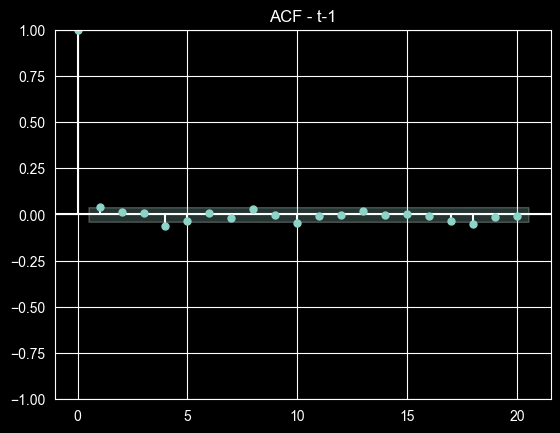

<Figure size 1000x500 with 0 Axes>

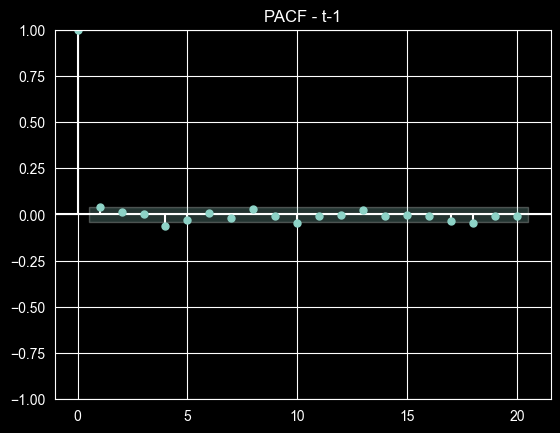

<Figure size 1000x500 with 0 Axes>

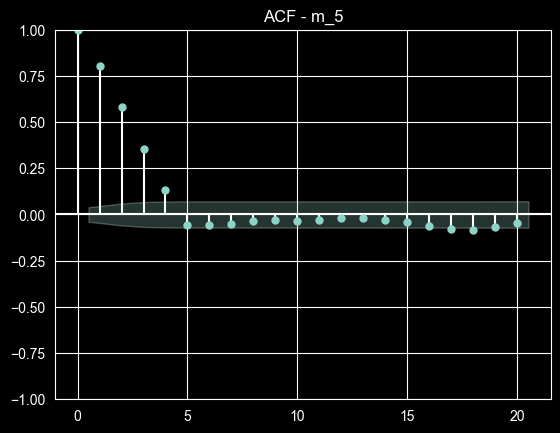

<Figure size 1000x500 with 0 Axes>

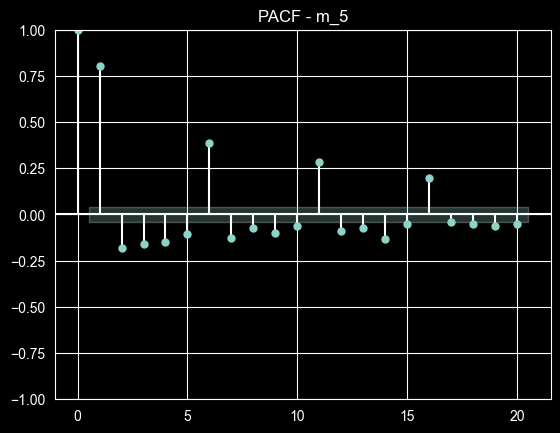

<Figure size 1000x500 with 0 Axes>

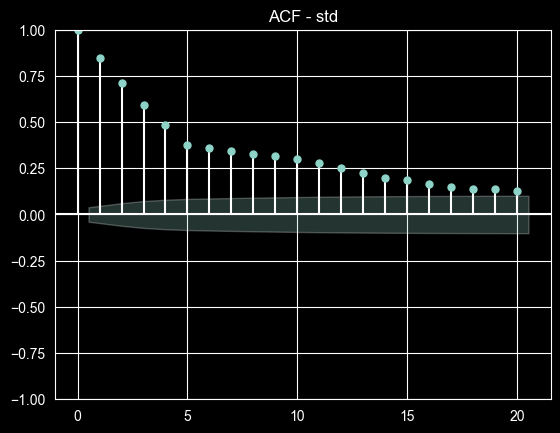

<Figure size 1000x500 with 0 Axes>

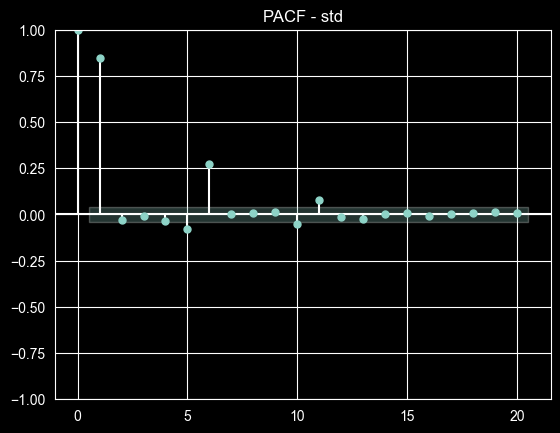

<Figure size 1000x500 with 0 Axes>

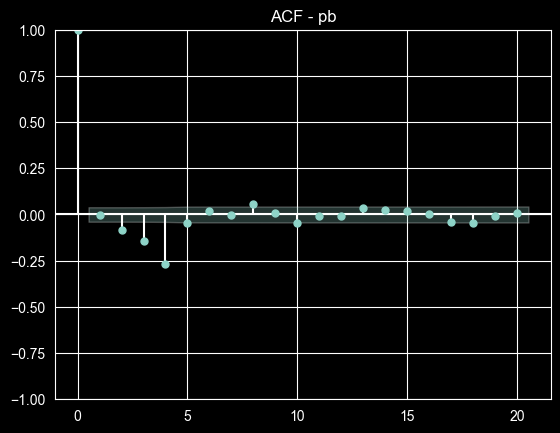

<Figure size 1000x500 with 0 Axes>

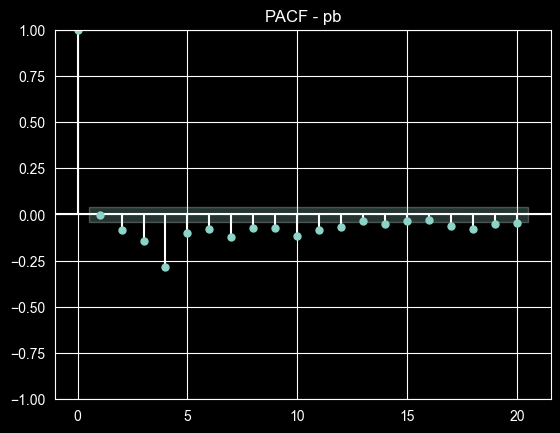

In [439]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
for col in x.columns:
    data = df[col].dropna()
    plt.figure(figsize=(10,5))
    plot_acf(data,lags =20)
    plt.title(f"ACF - {col}")
    plt.show()

    plt.figure(figsize=(10,5))
    plot_pacf(data,lags=20,method="ywm")
    plt.title(f"PACF - {col}")
    plt.show()


In [440]:
# checking autocorrelation in features
from statsmodels.stats.diagnostic import acorr_ljungbox
summary = {}
for col in x.columns:
    data = df[col].dropna()
    result = acorr_ljungbox(data,lags=20,return_df=True)
    summary[col] = result['lb_pvalue'].iloc[0]
print(summary)

{'t-1': 0.05637103841410017, 'm_5': 0.0, 'std': 0.0, 'pb': 0.8547787022183242}


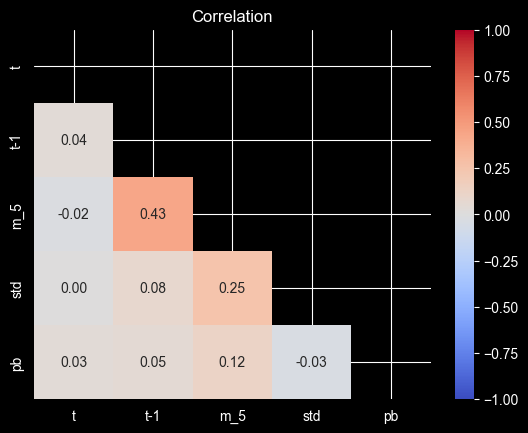

In [441]:
corr = df.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,cmap="coolwarm",center=0,annot=True,fmt=".2f",vmin=-1,vmax=1,mask=mask)
plt.title('Correlation')
plt.show()

In [442]:
# check Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
def remove_high_vif(x,threshold = 5):
    while True:
        vif = [variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
        max_vif = max(vif)
        if max_vif <= threshold :
            break
        drop_col = x.columns[vif.index(max_vif)]
        print(f"dropping {drop_col} (VIF={max_vif:.2f})")
        x = x.drop(columns=[drop_col])

    return x

<Axes: title={'center': 'Rolling Coefficients'}, xlabel='date'>

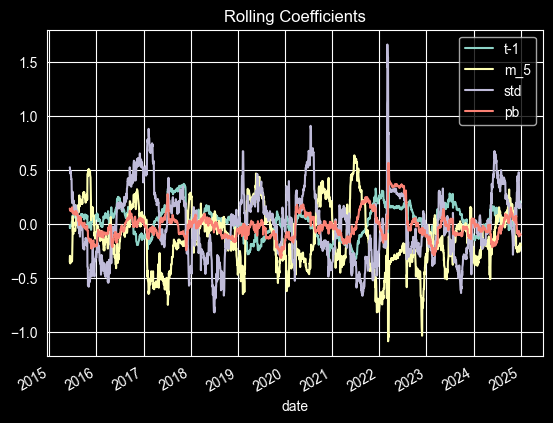

In [443]:
from sklearn.linear_model import LinearRegression

window = 100
pred = []
coef = []
date = []

for i in range (window,len(df)):

    x_train = x.iloc[i-window:i]
    y_train = y.iloc[i-window:i]

    x_test = x.iloc[i:i+1]

    model = LinearRegression().fit(x_train,y_train)

    y_pred = model.predict(x_test).item()
    pred.append(y_pred)
    coef.append(model.coef_)
    date.append(x_test.index[0])

# Predictions
results = pd.DataFrame({'date': date, 'pred': pred})
results['date'] = pd.to_datetime(results['date'])
results.set_index('date', inplace=True)

# Coefficients
coef_df = pd.DataFrame(coef, columns=x.columns, index=results.index)

# errors
results['actual'] = y.loc[results.index]
results['error'] = results['pred'] - results['actual']

# Plot

coef_df.plot(title="Rolling Coefficients")